# K-Nearest Neighbors

---

## Overview

**K-Nearest Neighbors (KNN)** is a non-parametric, instance-based classifier. To classify a new point $\mathbf{x}$:

1. Compute the **Euclidean distance** from $\mathbf{x}$ to every training point:
$$d(\mathbf{x}, \mathbf{x}^{(i)}) = \sqrt{\sum_{j=1}^{n} (x_j - x_j^{(i)})^2}$$

2. Find the $k$ nearest neighbors.

3. Predict by **majority vote** among the $k$ neighbors.

---

**Dataset:** Heart Disease (`heart.csv`). falls back to sklearn iris.
**Task:** Binary classification (heart disease: yes/no).


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.supervised_learning import KNN
from rice_ml.preprocess import StandardScaler, train_test_split
from rice_ml.metrics import accuracy_score, confusion_matrix


In [2]:
try:
    df = pd.read_csv('../../../data/heart.csv')
    X = df.drop(columns=['target']).values.astype(float)
    y = df['target'].values
    feature_names = df.drop(columns=['target']).columns.tolist()
    class_names = ['No Disease', 'Heart Disease']
    print(f'Loaded heart dataset: {X.shape}')
except FileNotFoundError:
    from sklearn.datasets import load_iris
    iris = load_iris()
    X, y = iris.data, iris.target
    feature_names = iris.feature_names
    class_names = list(iris.target_names)
    print('CSV not found. using iris dataset')

print(f'Dataset shape: {X.shape}')
print(f'Classes: {class_names}')


Loaded heart dataset: (1025, 13)
Dataset shape: (1025, 13)
Classes: ['No Disease', 'Heart Disease']


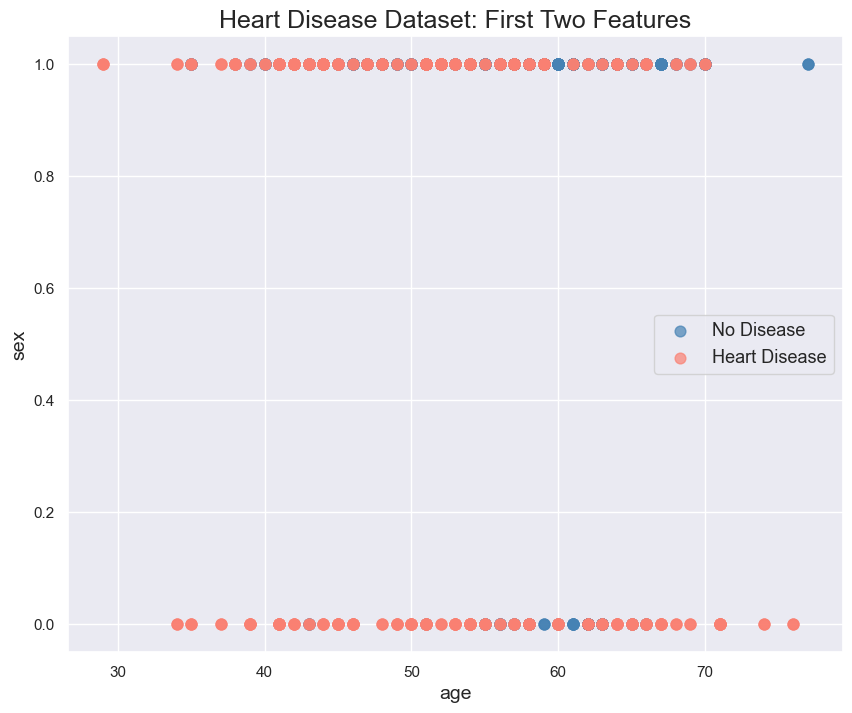

In [3]:
# Visualize first two features
colors = ['steelblue', 'salmon', 'lightseagreen']
plt.figure(figsize=(10, 8))
for i, cls in enumerate(class_names):
    mask = y == i
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[i], label=cls, s=60, alpha=0.7)
plt.xlabel(feature_names[0], fontsize=14)
plt.ylabel(feature_names[1], fontsize=14)
plt.title('Heart Disease Dataset: First Two Features', fontsize=18)
plt.legend(fontsize=13)
plt.show()


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Choosing $k$. Accuracy vs Number of Neighbors

A small $k$ leads to high variance (overfitting); a large $k$ leads to high bias (underfitting).

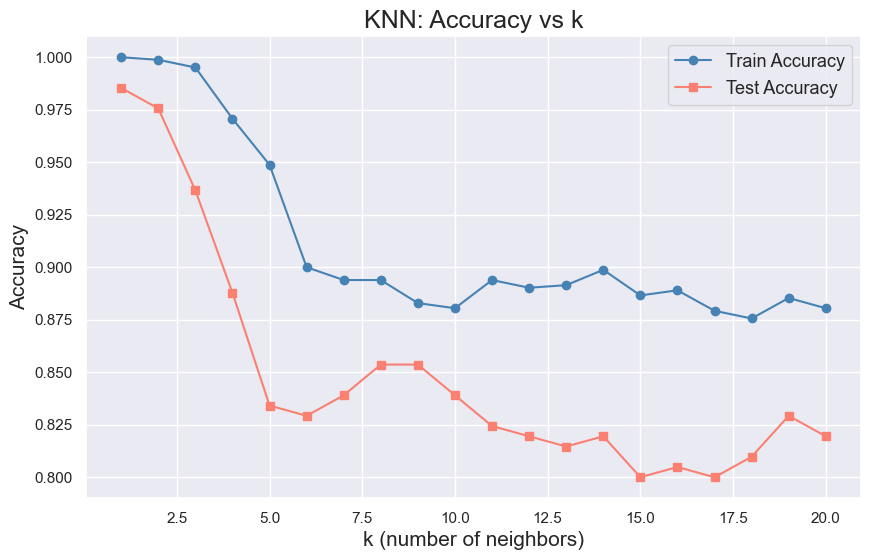

Best k = 1, Test Accuracy = 0.9854


In [5]:
k_values = range(1, 21)
train_accs, test_accs = [], []

for k in k_values:
    clf = KNN(k=k)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accs, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(k_values, test_accs, marker='s', label='Test Accuracy', color='salmon')
plt.xlabel('k (number of neighbors)', fontsize=15)
plt.ylabel('Accuracy', fontsize=15)
plt.title('KNN: Accuracy vs k', fontsize=18)
plt.legend(fontsize=13)
plt.show()

best_k = k_values[np.argmax(test_accs)]
print(f'Best k = {best_k}, Test Accuracy = {max(test_accs):.4f}')

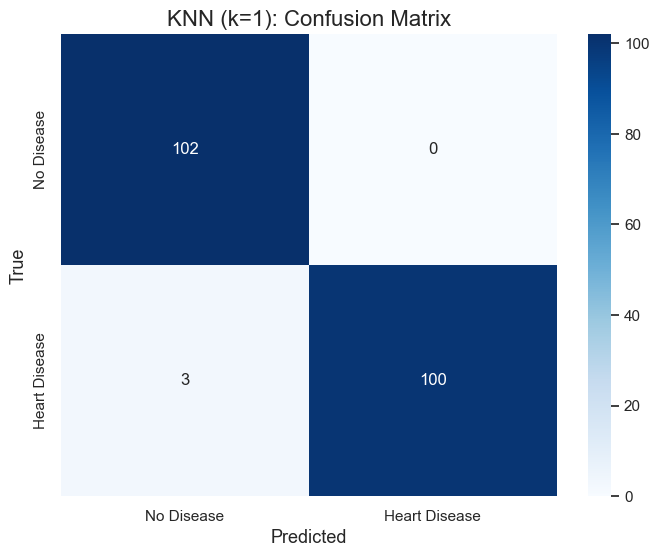

In [6]:
best_clf = KNN(k=best_k).fit(X_train, y_train)
y_pred = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('True', fontsize=13)
plt.title(f'KNN (k={best_k}): Confusion Matrix', fontsize=16)
plt.show()


## Interpretation

- KNN has **no explicit training phase**. it memorizes the training set and classifies at prediction time.
- The accuracy-vs-$k$ plot shows a bias-variance tradeoff: $k=1$ perfectly memorizes training data but may overfit.
- Feature scaling (StandardScaler) is critical since KNN relies on distances.